In [1]:
import torch
import cv2
import numpy as np
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

/opt/dlami/nvme/mitunet_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS_PATH = "/opt/dlami/nvme/mitunet_weights/mitunet.pth"

In [3]:
aux_segformer = smp.Segformer(encoder_name="mit_b4", encoder_weights=None)
model = smp.Unet(
    encoder_name="mit_b4",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
)
# Transplant the encoder
model.encoder = aux_segformer.encoder

# 3. Load trained weights
state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

/tmp/ipykernel_17819/2368169390.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)


Unet(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=64

In [4]:
transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [5]:

def predict(img_path, mask_path=None, show=True):

    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    augmented = transform(image=image_rgb)
    input_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        mask = (probs > 0.5).float()

    result_mask = mask.squeeze().cpu().numpy()

    # ---------------------------------
    # Load GT mask if provided
    # ---------------------------------
    gt_mask = None

    if mask_path is not None:
        gt_mask = cv2.imread(mask_path, 0)

        # wall only
        gt_mask = (gt_mask == 1).astype(np.uint8)

    # ---------------------------------
    # Plot
    # ---------------------------------
    if show:

        cols = 3 if gt_mask is not None else 2

        plt.figure(figsize=(18, 6))

        # Original image
        plt.subplot(1, cols, 1)
        plt.title("Original Image")
        plt.imshow(image_rgb)
        plt.axis('off')

        # Prediction
        plt.subplot(1, cols, 2)
        plt.title("Predicted Mask")
        plt.imshow(result_mask, cmap='gray')
        plt.axis('off')

        # GT mask
        if gt_mask is not None:
            plt.subplot(1, cols, 3)
            plt.title("GT Wall Mask")
            plt.imshow(gt_mask, cmap='gray')
            plt.axis('off')

        plt.show()

    return result_mask

  0%|          | 0/2 [00:00<?, ?it/s]

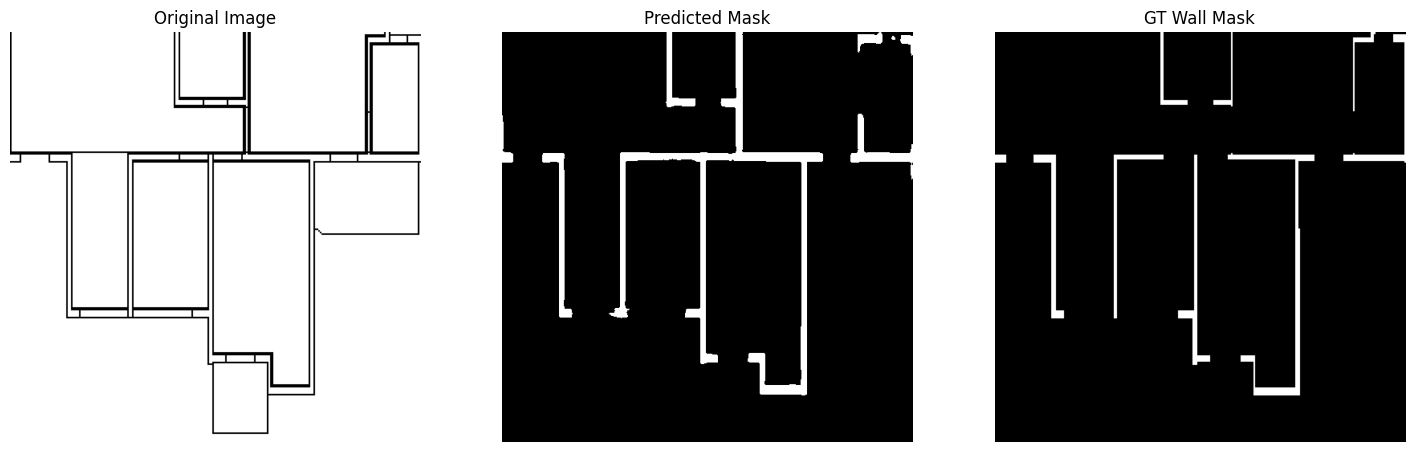

 50%|█████     | 1/2 [00:00<00:00,  1.70it/s]

<class 'numpy.ndarray'>


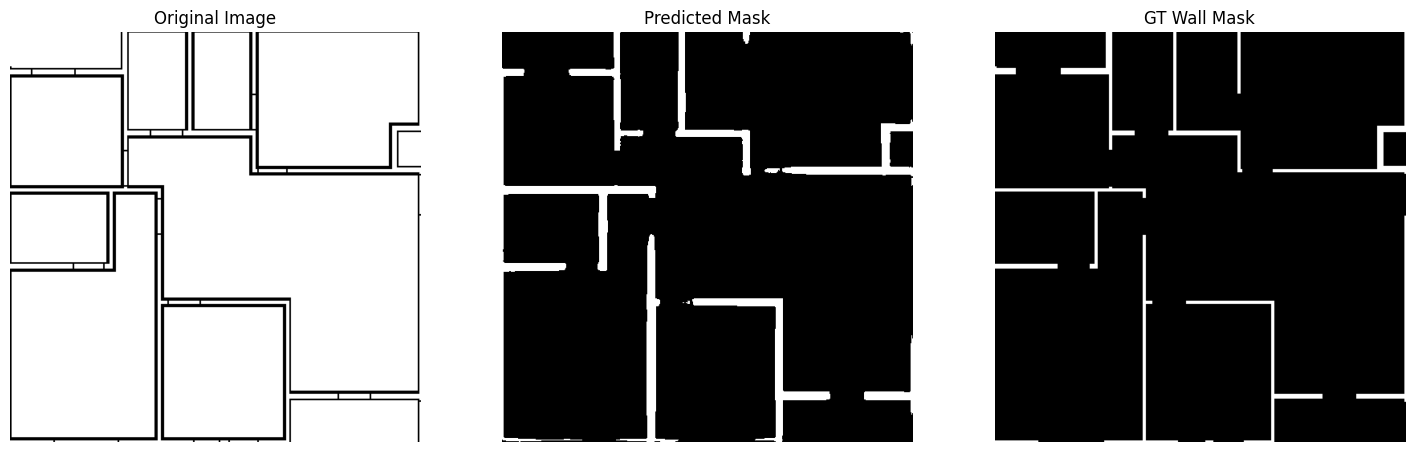

100%|██████████| 2/2 [00:00<00:00,  2.13it/s]

<class 'numpy.ndarray'>
mIoU : 0.4949354401976278
mAP  : 0.4731386698060951


In [6]:
import numpy as np
from sklearn.metrics import jaccard_score, average_precision_score
from tqdm import tqdm

ious = []
aps = []

dataset_path = "/opt/dlami/nvme/mitunet_dataset_1/images"
mask_path    = "/opt/dlami/nvme/mitunet_dataset_1/masks"

for i in tqdm(range(2)):

    # -----------------------------
    # Image path
    # -----------------------------
    img_path = f"{dataset_path}/{i:05d}.png"

    # -----------------------------
    # Ground truth mask
    # -----------------------------
    gt_mask = cv2.imread(
        f"{mask_path}/{i:05d}.png",
        0
    )

    # Wall class only
    gt_wall = (gt_mask == 1).astype(np.uint8)

    # -----------------------------
    # Prediction
    # -----------------------------
    pred_mask = predict(img_path, mask_path=f"{mask_path}/{i:05d}.png", show=True)

    print(type(pred_mask))

    # Binary prediction
    pred_wall = (pred_mask > 0).astype(np.uint8)
    # resize prediction to GT mask size
    pred_wall = cv2.resize(
        pred_wall.astype(np.uint8),
        (gt_wall.shape[1], gt_wall.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # -----------------------------
    # Flatten
    # -----------------------------
    gt   = gt_wall.flatten()
    pred = pred_wall.flatten()

    # -----------------------------
    # IoU
    # -----------------------------
    iou = jaccard_score(
        gt,
        pred,
        average="binary"
    )

    ious.append(iou)

    # -----------------------------
    # AP
    # -----------------------------
    ap = average_precision_score(
        gt,
        pred
    )

    aps.append(ap)

# -----------------------------
# Final metrics
# -----------------------------
print("mIoU :", np.mean(ious))
print("mAP  :", np.mean(aps))

In [7]:
import numpy as np
from skimage.morphology import skeletonize

def extract_line_points(mask):
    """
    mask:
        binary numpy array
        0 = background
        1 = wall/line

    Returns:
        endpoints : [(x, y), ...]
        junctions : [(x, y), ...]
    """

    # skeletonize
    skel = skeletonize(mask).astype(np.uint8)

    endpoints = []
    junctions = []

    h, w = skel.shape

    for y in range(1, h - 1):
        for x in range(1, w - 1):

            if skel[y, x] == 0:
                continue

            # count neighbors
            neighbors = np.sum(
                skel[y-1:y+2, x-1:x+2]
            ) - skel[y, x]

            if neighbors == 1:
                endpoints.append((x, y))

            elif neighbors >= 3:
                junctions.append((x, y))

    return endpoints, junctions

In [8]:
img_path = f"{dataset_path}/{0:05d}.png"
pred_wall = predict(img_path, show=False)

print(pred_wall, np.max(pred_wall), np.min(pred_wall))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] 1.0 0.0


In [9]:
endpoints, junctions = extract_line_points(pred_wall)

print("Endpoints:", endpoints)
print("Junctions:", junctions)

Endpoints: [(207, 2), (294, 3), (471, 3), (486, 6), (488, 9), (502, 9), (444, 25), (510, 29), (236, 88), (277, 88), (445, 106), (510, 142), (56, 157), (394, 157), (8, 158), (439, 158), (510, 183), (158, 346), (81, 351), (134, 352), (229, 354), (155, 355), (264, 408), (250, 410), (307, 410)]
Junctions: [(294, 88), (293, 89), (294, 89), (294, 90), (295, 155), (294, 156), (295, 156), (296, 156), (375, 156), (376, 156), (377, 156), (447, 156), (506, 156), (249, 157), (376, 157), (446, 157), (447, 157), (448, 157), (505, 157), (506, 157), (150, 347), (150, 348), (151, 348), (150, 349), (149, 350), (150, 350), (248, 350), (150, 351), (247, 351), (248, 351), (251, 406), (251, 407), (252, 407), (251, 408)]


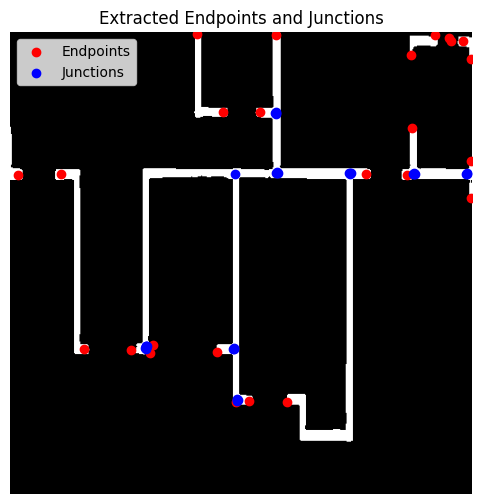

In [10]:
# plot the points on the mask image
plt.figure(figsize=(6, 6))
plt.imshow(pred_wall, cmap='gray')
if endpoints:
    ex, ey = zip(*endpoints)
    plt.scatter(ex, ey, c='red', label='Endpoints')
if junctions:
    jx, jy = zip(*junctions)
    plt.scatter(jx, jy, c='blue', label='Junctions')
plt.legend()
plt.title("Extracted Endpoints and Junctions")
plt.axis('off')
plt.show()

In [24]:
import numpy as np
from skimage.morphology import skeletonize
from collections import deque

def build_graph_from_mask(mask):
    """
    mask:
        binary image (0/1)

    Returns:
        graph = {
            "nodes": {node_id: (x, y)},
            "edges": [(node_a, node_b, path_pixels)]
        }
    """

    # skel = skeletonize(mask).astype(np.uint8)

    # # apply hough transform to connect broken lines
    # lines = cv2.HoughLinesP(
    #     skel,
    #     rho=1,
    #     theta=np.pi/180,
    #     threshold=50,
    #     minLineLength=5,
    #     maxLineGap=10
    # )

    # after skeletonization
    skel = skeletonize(mask).astype(np.uint8)

    # create clean straight-line skeleton
    clean = np.zeros_like(skel)

    lines = cv2.HoughLinesP(
        skel,
        rho=1,
        theta=np.pi/180,
        threshold=20,
        minLineLength=10,
        maxLineGap=15
    )

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            cv2.line(
                clean,
                (x1, y1),
                (x2, y2),
                1,
                1
            )

    # use this instead
    skel = clean

    h, w = skel.shape

    # # -------------------------------------------------
    # # STEP 1: detect nodes
    # # -------------------------------------------------
    # nodes = {}
    # node_pixels = set()

    # node_id = 0

    # for y in range(1, h - 1):
    #     for x in range(1, w - 1):

    #         if skel[y, x] == 0:
    #             continue

    #         neighbors = np.sum(
    #             skel[y-1:y+2, x-1:x+2]
    #         ) - skel[y, x]

    #         # endpoint or junction
    #         if neighbors == 1 or neighbors >= 3:
    #             nodes[node_id] = (x, y)
    #             node_pixels.add((x, y))
    #             node_id += 1

    # -------------------------------------------------
    # STEP 1: detect nodes
    # -------------------------------------------------
    nodes = {}
    node_pixels = set()

    node_id = 0

    directions = [
        (-1, 0), (1, 0),
        (0, -1), (0, 1)
    ]

    for y in range(1, h - 1):
        for x in range(1, w - 1):

            if skel[y, x] == 0:
                continue

            neighbors_coords = []

            for dx, dy in directions:

                nx, ny = x + dx, y + dy

                if skel[ny, nx] == 1:
                    neighbors_coords.append((dx, dy))

            neighbor_count = len(neighbors_coords)

            is_endpoint = neighbor_count == 1
            is_junction = neighbor_count >= 3

            is_corner = False

            # exact L-corner
            if neighbor_count == 2:

                p1, p2 = neighbors_coords

                # not opposite directions
                if p1[0] != -p2[0] or p1[1] != -p2[1]:
                    is_corner = True

            if is_endpoint or is_junction or is_corner:
                nodes[node_id] = (x, y)
                node_pixels.add((x, y))
                node_id += 1

    # -------------------------------------------------
    # STEP 2: graph traversal
    # -------------------------------------------------
    visited = set()
    edges = []

    directions = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1)
    ]

    def get_neighbors(px, py):
        result = []

        for dx, dy in directions:
            nx, ny = px + dx, py + dy

            if (
                0 <= nx < w and
                0 <= ny < h and
                skel[ny, nx] == 1
            ):
                result.append((nx, ny))

        return result

    # node lookup
    pixel_to_node = {
        coord: nid for nid, coord in nodes.items()
    }

    # -------------------------------------------------
    # traverse from every node
    # -------------------------------------------------
    for start_id, (sx, sy) in nodes.items():

        for neighbor in get_neighbors(sx, sy):

            edge_key = tuple(sorted([(sx, sy), neighbor]))

            if edge_key in visited:
                continue

            path = [(sx, sy)]

            prev = (sx, sy)
            curr = neighbor

            while True:

                path.append(curr)

                visited.add(
                    tuple(sorted([prev, curr]))
                )

                # reached another node
                if curr in node_pixels and curr != (sx, sy):

                    end_id = pixel_to_node[curr]

                    edges.append(
                        (start_id, end_id, path)
                    )

                    break

                nbrs = get_neighbors(*curr)

                # remove previous pixel
                nbrs = [p for p in nbrs if p != prev]

                if len(nbrs) == 0:
                    break

                prev = curr
                curr = nbrs[0]

    graph = {
        "nodes": nodes,
        "edges": edges
    }

    return graph

In [25]:
graph = build_graph_from_mask(pred_wall)
print("Nodes:")
for nid, (x, y) in graph["nodes"].items():
    print(f"  {nid}: ({x}, {y})")
print("Edges:")
for node_a, node_b, path in graph["edges"]:
    print(f"  {node_a} <-> {node_b}, path length: {len(path)}")

Nodes:
  0: (208, 4)
  1: (295, 5)
  2: (448, 9)
  3: (468, 9)
  4: (510, 15)
  5: (510, 29)
  6: (208, 86)
  7: (215, 88)
  8: (236, 88)
  9: (446, 108)
  10: (446, 132)
  11: (447, 133)
  12: (510, 142)
  13: (218, 155)
  14: (240, 155)
  15: (174, 156)
  16: (217, 156)
  17: (241, 156)
  18: (250, 156)
  19: (295, 156)
  20: (376, 156)
  21: (389, 156)
  22: (461, 156)
  23: (483, 156)
  24: (56, 157)
  25: (71, 157)
  26: (151, 157)
  27: (173, 157)
  28: (440, 157)
  29: (447, 157)
  30: (460, 157)
  31: (484, 157)
  32: (506, 157)
  33: (150, 158)
  34: (73, 160)
  35: (73, 175)
  36: (74, 176)
  37: (510, 183)
  38: (74, 349)
  39: (150, 351)
  40: (376, 371)
  41: (375, 372)
  42: (375, 404)
  43: (376, 405)
  44: (250, 410)
  45: (324, 410)
  46: (376, 437)
  47: (324, 444)
  48: (336, 446)
  49: (373, 446)
Edges:
  0 <-> 6, path length: 83
  1 <-> 18, path length: 196
  2 <-> 3, path length: 21
  4 <-> 5, path length: 15
  7 <-> 8, path length: 22
  9 <-> 10, path length: 25


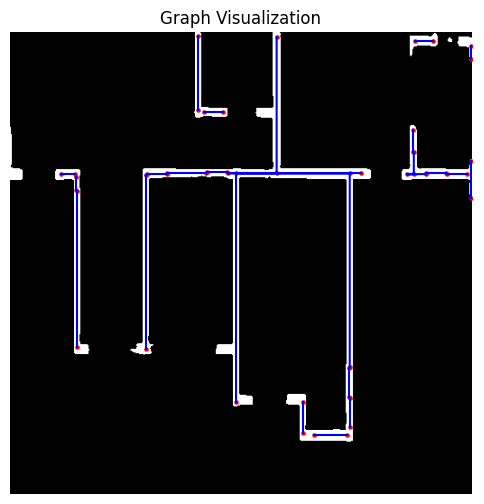

In [26]:
# plot this graph now
plt.figure(figsize=(6, 6))
plt.imshow(pred_wall, cmap='gray')
for nid, (x, y) in graph["nodes"].items():
    plt.scatter(x, y, c='red', s=5)
    plt.text(x+2, y+2, str(nid), color='red', fontsize=0)
for node_a, node_b, path in graph["edges"]:
    px, py = zip(*path)
    plt.plot(px, py, c='blue')
plt.title("Graph Visualization")
plt.axis('off')
plt.show()